In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/freight_Rate_Assessment(ML)"

train_df = pd.read_csv(f"{DATA_PATH}/train-test.csv")

train_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
## Data
print("Shape:", train_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nData Types:")
print(train_df.dtypes)

Shape: (48000, 14)

Columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Data Types:
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object


In [4]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [6]:
train_df.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [7]:
print("Duplicate rows:", train_df.duplicated().sum())
print("Duplicate load IDs:", train_df["load_id"].duplicated().sum())

Duplicate rows: 0
Duplicate load IDs: 0


In [8]:
for col in ["pickup", "delivery", "equipment"]:
    print(col, ":", train_df[col].nunique(), "unique values")

pickup : 64 unique values
delivery : 64 unique values
equipment : 3 unique values


In [9]:
train_df["posted_rate"].describe()

,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


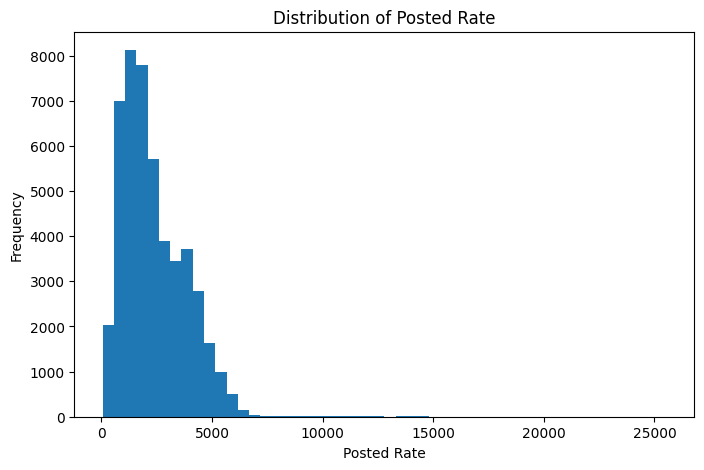

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_df["posted_rate"], bins=50)
plt.xlabel("Posted Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Posted Rate")
plt.show()

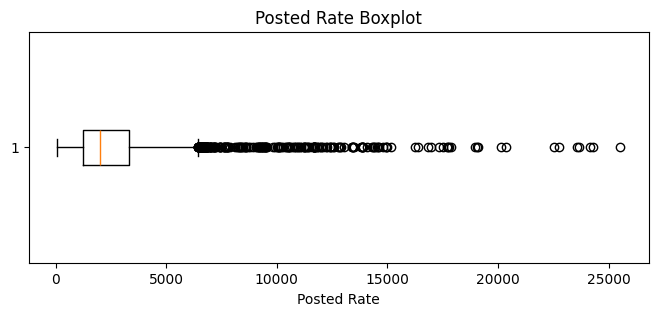

In [11]:
plt.figure(figsize=(8, 3))
plt.boxplot(train_df["posted_rate"], vert=False)
plt.xlabel("Posted Rate")
plt.title("Posted Rate Boxplot")
plt.show()

In [12]:
train_df[["distance", "weight", "market_index", "quote_signal", "posted_rate"]].corr()

,distance,weight,market_index,quote_signal,posted_rate
distance,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,0.908519,0.034840,0.034165,-0.039858,1.000000


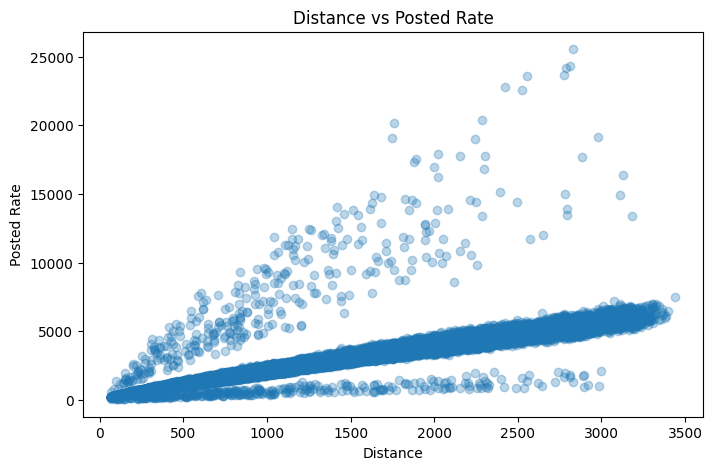

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df["distance"], train_df["posted_rate"], alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.title("Distance vs Posted Rate")
plt.show()

In [14]:
train_df.groupby("equipment")["posted_rate"].agg(["count", "mean", "median"])

,count,mean,median
equipment,,,
Dry Van,27202,2271.548686,1953.035
Flatbed,8753,2445.087223,2076.810
Reefer,12045,2553.636939,2196.670


In [15]:
train_df["equipment"].value_counts()

,count
equipment,
Dry Van,27202
Reefer,12045
Flatbed,8753


In [16]:
train_df["rate_per_mile"] = train_df["posted_rate"] / train_df["distance"]

train_df["rate_per_mile"].describe()

,rate_per_mile
count,48000.000000
mean,2.215347
std,0.583887
min,0.333709
25%,1.986974
50%,2.145348
75%,2.342696
max,14.125294


In [17]:
train_df.groupby("equipment")["rate_per_mile"].agg(["count", "mean", "median"])

,count,mean,median
equipment,,,
Dry Van,27202,2.115401,2.046203
Flatbed,8753,2.294729,2.219683
Reefer,12045,2.383376,2.311540


In [18]:
train_df["date"] = pd.to_datetime(train_df["date"])

print("Earliest date:", train_df["date"].min())
print("Latest date:", train_df["date"].max())

Earliest date: 2025-01-01 00:00:00
Latest date: 2025-10-31 00:00:00


pre processing


In [19]:
# Make a copy so we keep the original data unchanged
data = train_df.copy()

# Convert date to datetime
data["date"] = pd.to_datetime(data["date"])

# Create useful date features
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["day_of_week"] = data["date"].dt.dayofweek

data[["date", "month", "day", "day_of_week"]].head()

,date,month,day,day_of_week
0,2025-01-01,1,1,2
1,2025-01-01,1,1,2
2,2025-01-01,1,1,2
3,2025-01-01,1,1,2
4,2025-01-01,1,1,2


In [20]:
train_data = data[data["date"] < "2025-10-01"].copy()
val_data = data[data["date"] >= "2025-10-01"].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(val_data))

print("\nTraining period:",
      train_data["date"].min(), "to", train_data["date"].max())

print("Validation period:",
      val_data["date"].min(), "to", val_data["date"].max())

Training rows: 43147
Validation rows: 4853

Training period: 2025-01-01 00:00:00 to 2025-09-30 00:00:00
Validation period: 2025-10-01 00:00:00 to 2025-10-31 00:00:00


Baseline Model **bold text**

In [21]:
from sklearn.metrics import mean_absolute_error

baseline_value = train_data["posted_rate"].mean()

baseline_predictions = [baseline_value] * len(val_data)

baseline_mae = mean_absolute_error(
    val_data["posted_rate"],
    baseline_predictions
)

print("Baseline mean:", baseline_value)
print("Baseline MAE:", baseline_mae)

Baseline mean: 2373.4103513569885
Baseline MAE: 1179.7959780864721


linear regression Distance baseline

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Feature and target
X_train_distance = train_data[["distance"]]
y_train = train_data["posted_rate"]

X_val_distance = val_data[["distance"]]
y_val = val_data["posted_rate"]

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train_distance, y_train)

# Predict October rates
linear_predictions = linear_model.predict(X_val_distance)

# Evaluate
linear_mae = mean_absolute_error(y_val, linear_predictions)

print("Baseline MAE:", baseline_mae)
print("Linear Regression MAE:", linear_mae)

Baseline MAE: 1179.7959780864721
Linear Regression MAE: 192.7741904419589


preprocessing pipeline



In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Features we want to use
numeric_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "month",
    "day",
    "day_of_week"
]

categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

# Numeric preprocessing:
# fill missing values with the median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing:
# fill missing values if any, then convert text to numbers
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Random forest Model


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Select features and target
X_train = train_data[numeric_features + categorical_features]
y_train = train_data["posted_rate"]

X_val = val_data[numeric_features + categorical_features]
y_val = val_data["posted_rate"]

# Build full pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_val)

# Evaluate
rf_mae = mean_absolute_error(y_val, rf_predictions)

print("Linear Regression MAE:", linear_mae)
print("Random Forest MAE:", rf_mae)

Linear Regression MAE: 192.7741904419589
Random Forest MAE: 158.69024741397075


Gradient Boosting Model

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_val)

gb_mae = mean_absolute_error(y_val, gb_predictions)

print("Linear Regression MAE:", linear_mae)
print("Random Forest MAE:", rf_mae)
print("Gradient Boosting MAE:", gb_mae)

Linear Regression MAE: 192.7741904419589
Random Forest MAE: 158.69024741397075
Gradient Boosting MAE: 118.3130657248302


catboost


In [27]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [28]:
from catboost import CatBoostRegressor

cat_features = ["pickup", "delivery", "equipment"]

features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day",
    "day_of_week"
]

X_train_cat = train_data[features].copy()
X_val_cat = val_data[features].copy()

for col in cat_features:
    X_train_cat[col] = X_train_cat[col].fillna("Missing").astype(str)
    X_val_cat[col] = X_val_cat[col].fillna("Missing").astype(str)

cat_model = CatBoostRegressor(
    iterations=800,
    depth=8,
    learning_rate=0.05,
    loss_function="MAE",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features
)

cat_predictions = cat_model.predict(X_val_cat)

cat_mae = mean_absolute_error(y_val, cat_predictions)

print("Linear Regression MAE:", linear_mae)
print("Random Forest MAE:", rf_mae)
print("Gradient Boosting MAE:", gb_mae)
print("CatBoost MAE:", cat_mae)

Linear Regression MAE: 192.7741904419589
Random Forest MAE: 158.69024741397075
Gradient Boosting MAE: 118.3130657248302
CatBoost MAE: 116.08627443585715


lightgbm

In [35]:
!pip install lightgbm -q

In [36]:
from lightgbm import LGBMRegressor

lgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_predictions = lgbm_model.predict(X_val)

lgbm_mae = mean_absolute_error(
    y_val,
    lgbm_predictions
)

print("CatBoost MAE:", cat_mae)
print("LightGBM MAE:", lgbm_mae)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1589
[LightGBM] [Info] Number of data points in the train set: 43147, number of used features: 142
[LightGBM] [Info] Start training from score 2373.410351


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost MAE: 116.08627443585715
LightGBM MAE: 174.46548778075402


In [ ]:
## Advanced LightGBM with Feature Engineering and Log Target

In [37]:
for df in [train_data, val_data]:
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    df["weight_per_distance"] = (
        df["weight"] / (df["distance"] + 1)
    )

    df["lat_diff"] = (
        df["delivery_lat"] - df["pickup_lat"]
    ).abs()

    df["lon_diff"] = (
        df["delivery_lon"] - df["pickup_lon"]
    ).abs()

In [38]:
advanced_numeric_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "month",
    "day",
    "day_of_week",
    "is_weekend",
    "weight_per_distance",
    "lat_diff",
    "lon_diff"
]

advanced_categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

advanced_preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         Pipeline(steps=[
             ("imputer", SimpleImputer(strategy="median"))
         ]),
         advanced_numeric_features),

        ("cat",
         Pipeline(steps=[
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("onehot", OneHotEncoder(handle_unknown="ignore"))
         ]),
         advanced_categorical_features)
    ]
)

X_train_adv = train_data[
    advanced_numeric_features + advanced_categorical_features
]

X_val_adv = val_data[
    advanced_numeric_features + advanced_categorical_features
]

In [39]:
import numpy as np

y_train_log = np.log1p(y_train)

In [40]:
from lightgbm import LGBMRegressor

lgbm_adv_model = Pipeline(steps=[
    ("preprocessor", advanced_preprocessor),
    ("model", LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_adv_model.fit(X_train_adv, y_train_log)

lgbm_adv_log_predictions = lgbm_adv_model.predict(X_val_adv)

lgbm_adv_predictions = np.expm1(
    lgbm_adv_log_predictions
)

lgbm_adv_mae = mean_absolute_error(
    y_val,
    lgbm_adv_predictions
)

print("CatBoost MAE:", cat_mae)
print("Advanced LightGBM MAE:", lgbm_adv_mae)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2356
[LightGBM] [Info] Number of data points in the train set: 43147, number of used features: 146
[LightGBM] [Info] Start training from score 7.573844


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost MAE: 116.08627443585715
Advanced LightGBM MAE: 156.85314557092224


In [ ]:
##CatBoost + Early Stopping

In [41]:
cat_best_model = CatBoostRegressor(
    iterations=3000,
    depth=8,
    learning_rate=0.03,
    loss_function="MAE",
    random_seed=42,
    verbose=False
)

cat_best_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val_cat, y_val),
    early_stopping_rounds=100,
    verbose=False
)

cat_best_predictions = cat_best_model.predict(X_val_cat)

cat_best_mae = mean_absolute_error(
    y_val,
    cat_best_predictions
)

print("Original CatBoost MAE:", cat_mae)
print("CatBoost + Early Stopping MAE:", cat_best_mae)
print("Best iteration:", cat_best_model.get_best_iteration())

Original CatBoost MAE: 116.08627443585715
CatBoost + Early Stopping MAE: 112.16984406530743
Best iteration: 460


In [ ]:
##

In [42]:
for df in [train_data, val_data]:

    # Weekend indicator
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # Weight relative to trip distance
    df["weight_per_distance"] = (
        df["weight"] / (df["distance"] + 1)
    )

    # Geographic differences
    df["lat_diff"] = (
        df["delivery_lat"] - df["pickup_lat"]
    ).abs()

    df["lon_diff"] = (
        df["delivery_lon"] - df["pickup_lon"]
    ).abs()

    # Combined geographic difference
    df["manhattan_dist"] = (
        df["lat_diff"] + df["lon_diff"]
    )

    # Relationship between market signals
    df["market_quote_ratio"] = (
        df["market_index"] / (df["quote_signal"] + 1e-5)
    )

In [43]:
safe_features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day",
    "day_of_week",
    "is_weekend",
    "weight_per_distance",
    "lat_diff",
    "lon_diff",
    "manhattan_dist",
    "market_quote_ratio"
]

X_train_safe = train_data[safe_features].copy()
X_val_safe = val_data[safe_features].copy()

for col in cat_features:
    X_train_safe[col] = X_train_safe[col].fillna("Missing").astype(str)
    X_val_safe[col] = X_val_safe[col].fillna("Missing").astype(str)

In [44]:
cat_safe_model = CatBoostRegressor(
    iterations=3000,
    depth=8,
    learning_rate=0.03,
    loss_function="MAE",
    random_seed=42,
    verbose=False
)

cat_safe_model.fit(
    X_train_safe,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val_safe, y_val),
    early_stopping_rounds=100,
    verbose=False
)

cat_safe_predictions = cat_safe_model.predict(X_val_safe)

cat_safe_mae = mean_absolute_error(
    y_val,
    cat_safe_predictions
)

print("CatBoost + Early Stopping MAE:", cat_best_mae)
print("CatBoost + Safe Features MAE:", cat_safe_mae)
print("Best iteration:", cat_safe_model.get_best_iteration())

CatBoost + Early Stopping MAE: 112.16984406530743
CatBoost + Safe Features MAE: 108.29122548878024
Best iteration: 575


Group-Based Missing Value Imputation

In [47]:
train_imp = train_data.copy()
val_imp = val_data.copy()

# 1) Weight: fill using median weight per equipment type
weight_medians = train_imp.groupby("equipment")["weight"].median()

train_imp["weight"] = train_imp["weight"].fillna(
    train_imp["equipment"].map(weight_medians)
)

val_imp["weight"] = val_imp["weight"].fillna(
    val_imp["equipment"].map(weight_medians)
)

# Fallback in case any value is still missing
global_weight_median = train_data["weight"].median()

train_imp["weight"] = train_imp["weight"].fillna(global_weight_median)
val_imp["weight"] = val_imp["weight"].fillna(global_weight_median)


# 2) Market index: fill using median market index per month
market_month_medians = train_imp.groupby("month")["market_index"].median()

train_imp["market_index"] = train_imp["market_index"].fillna(
    train_imp["month"].map(market_month_medians)
)

val_imp["market_index"] = val_imp["market_index"].fillna(
    val_imp["month"].map(market_month_medians)
)

# Fallback
global_market_median = train_data["market_index"].median()

train_imp["market_index"] = train_imp["market_index"].fillna(global_market_median)
val_imp["market_index"] = val_imp["market_index"].fillna(global_market_median)

print("Training missing values:")
print(train_imp[["weight", "market_index"]].isnull().sum())

print("\nValidation missing values:")
print(val_imp[["weight", "market_index"]].isnull().sum())

Training missing values:
weight          0
market_index    0
dtype: int64

Validation missing values:
weight          0
market_index    0
dtype: int64


In [48]:
for df in [train_imp, val_imp]:
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    df["weight_per_distance"] = (
        df["weight"] / (df["distance"] + 1)
    )

    df["lat_diff"] = (
        df["delivery_lat"] - df["pickup_lat"]
    ).abs()

    df["lon_diff"] = (
        df["delivery_lon"] - df["pickup_lon"]
    ).abs()

    df["manhattan_dist"] = (
        df["lat_diff"] + df["lon_diff"]
    )

    df["market_quote_ratio"] = (
        df["market_index"] / (df["quote_signal"] + 1e-5)
    )

In [49]:
X_train_imp = train_imp[safe_features].copy()
X_val_imp = val_imp[safe_features].copy()

for col in cat_features:
    X_train_imp[col] = X_train_imp[col].fillna("Missing").astype(str)
    X_val_imp[col] = X_val_imp[col].fillna("Missing").astype(str)

In [50]:
cat_imp_model = CatBoostRegressor(
    iterations=3000,
    depth=8,
    learning_rate=0.03,
    loss_function="MAE",
    random_seed=42,
    verbose=False
)

cat_imp_model.fit(
    X_train_imp,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val_imp, y_val),
    early_stopping_rounds=100,
    verbose=False
)

cat_imp_predictions = cat_imp_model.predict(X_val_imp)

cat_imp_mae = mean_absolute_error(
    y_val,
    cat_imp_predictions
)

print("Previous best MAE:", cat_safe_mae)
print("Group-Imputation MAE:", cat_imp_mae)
print("Best iteration:", cat_imp_model.get_best_iteration())

Previous best MAE: 108.29122548878024
Group-Imputation MAE: 107.5315617314066
Best iteration: 669


In [ ]:
#add continuous time feature

In [51]:
reference_date = train_imp["date"].min()

train_imp["days_since_start"] = (
    train_imp["date"] - reference_date
).dt.days

val_imp["days_since_start"] = (
    val_imp["date"] - reference_date
).dt.days

In [52]:
safe_features_time = safe_features + ["days_since_start"]

X_train_time = train_imp[safe_features_time].copy()
X_val_time = val_imp[safe_features_time].copy()

for col in cat_features:
    X_train_time[col] = X_train_time[col].fillna("Missing").astype(str)
    X_val_time[col] = X_val_time[col].fillna("Missing").astype(str)

In [53]:
cat_time_model = CatBoostRegressor(
    iterations=3000,
    depth=8,
    learning_rate=0.03,
    loss_function="MAE",
    random_seed=42,
    verbose=False
)

cat_time_model.fit(
    X_train_time,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val_time, y_val),
    early_stopping_rounds=100,
    verbose=False
)

cat_time_predictions = cat_time_model.predict(X_val_time)

cat_time_mae = mean_absolute_error(
    y_val,
    cat_time_predictions
)

print("Previous best MAE:", cat_imp_mae)
print("With days_since_start MAE:", cat_time_mae)
print("Best iteration:", cat_time_model.get_best_iteration())

Previous best MAE: 107.5315617314066
With days_since_start MAE: 109.31191193098843
Best iteration: 406
